## Building a chatbot with langgraph using langgraph api


In [43]:
from typing import Annotated   
# -> meta data for type hinting

from typing_extensions import TypedDict 
# -> for defining structured data types

from langgraph.graph import StateGraph,START,END 
# -> StateGraph is the main class for creating a graph, START and END are special nodes

from langgraph.graph.message import add_messages
# -> for adding messages to the graph without replacing the previous ones



In [44]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list, add_messages]  

In [45]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [46]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [47]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000016C43E65E50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000016C43E65BD0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

# Node Definition

In [48]:
## node functionality
def chatbot(state:State):
    return{"messages":[llm.invoke(state["messages"])]}

In [49]:
graph_builder=StateGraph(State)

## adding node
graph_builder.add_node("llmchatbot",chatbot)

## adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

# compiling the graph
graph=graph_builder.compile()

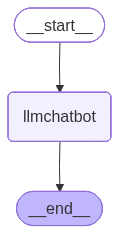

In [50]:
# visualizing the graph
from IPython.display import display,Image
try :
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception :
    pass

In [51]:
response=graph.invoke({"messages":"Hello, how are you?"})

In [52]:
response["messages"][-1].content

"Hello, I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?"

In [53]:
for event in graph.stream({"messages":"Hi there!"}):
    for value in event.values():
        print(value["messages"][-1].content)

It's nice to meet you. Is there something I can help you with or would you like to chat?


## CHATBOT WITH TOOL


In [54]:
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the navigat

In [55]:
#custom function
def multiply(a:int,b:int)->int:
    """"
    Multiply a & b
    Args:
        a: int : first int
        b: int : second int
    Returns:
        int: a*b
        """
    return a*b

In [56]:
tools=[tool,multiply]

In [57]:
llm_with_tools=llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000016C43E65E50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000016C43E65BD0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool del

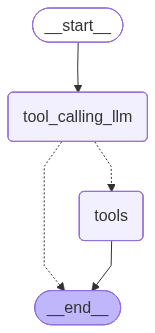

In [58]:
# stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# node definition
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

#graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# adding the edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routess to tools
    # if the latest message (result) from assistant is a not a toll call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compoling the graph  
graph=builder.compile()

## visualizing the graph
from IPython.display import display,Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [59]:
response=graph.invoke({"messages":"what is the recent ai news "})


In [60]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.mediapost.com/publications/article/415557/openai-embraces-retro-ads-to-humanize-ai-ahead-of.html", "title": "OpenAI Embraces Retro Ads To Humanize AI Ahead Of IPO 06/04/2026 - MediaPost", "score": 0.6824261, "published_date": "Thu, 04 Jun 2026 18:19:57 GMT", "content": "*   Become A MediaPost Member Subscribe to your choice of industry specific newsletters, save $100 on conferences, search member directories, comment on stories and more. Free to qualified media, marketing and advertising professionals. OpenAI’s recent retro message comes across loud and clear in a 30-second campaign that _The New York Times_ reported was done by the creative agency Isle of Any. It has a retro vibe and attempts to bring the viewer into the days before everyone carried smartphones. OpenAI wants users to know they can keep the human aspect of life and integrate technology to find the be

In [61]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (y2b19zz2q)
 Call ID: y2b19zz2q
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.mediapost.com/publications/article/415557/openai-embraces-retro-ads-to-humanize-ai-ahead-of.html", "title": "OpenAI Embraces Retro Ads To Humanize AI Ahead Of IPO 06/04/2026 - MediaPost", "score": 0.6824261, "published_date": "Thu, 04 Jun 2026 18:19:57 GMT", "content": "*   Become A MediaPost Member Subscribe to your choice of industry specific newsletters, save $100 on conferences, search member directories, comment on stories and more. Free to qualifi

In [62]:
response=graph.invoke({"messages":"what is 2 multiplied by 3 "})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 3 
================================== Ai Message ==================================
Tool Calls:
  multiply (myp7g290r)
 Call ID: myp7g290r
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [63]:
response=graph.invoke({"messages":"what is 2 multiplied by 3 then by 10  and tell me what is recent news about ai"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 3 then by 10  and tell me what is recent news about ai
================================== Ai Message ==================================
Tool Calls:
  multiply (yqf1qzztg)
 Call ID: yqf1qzztg
  Args:
    a: 2
    b: 3
  multiply (7tear90eh)
 Call ID: 7tear90eh
  Args:
    a: 6
    b: 10
  tavily_search (d718wgpfs)
 Call ID: d718wgpfs
  Args:
    query: recent news about AI
    search_depth: advanced
    start_date: 2024-01-01
    topic: news
================================= Tool Message =================================
Name: multiply

6
================================= Tool Message =================================
Name: multiply

60
================================= Tool Message =================================
Name: tavily_search

{"query": "recent news about AI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2025/01/08/

## building ReACT agent

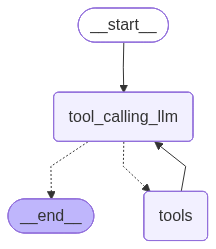

In [64]:

# stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# node definition
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

#graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# adding the edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routess to tools
    # if the latest message (result) from assistant is a not a toll call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compoling the graph  
graph=builder.compile()

## visualizing the graph
from IPython.display import display,Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [65]:
response=graph.invoke({"messages":"what is 2 multiplied by 3 then by 10  and tell me what is recent news about ai"})
for m in response["messages"]:
    m.pretty_print()

BadRequestError: Error code: 400 - {'error': {'message': 'tool call validation failed: attempted to call tool \'tavily_search({"query": "recent news about AI", "topic": "news", "time_range": "month", "search_depth": "advanced", "include_images": false, "start_date": null, "end_date": null, "include_domains": null, "exclude_domains": null})\' which was not in request.tools', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=tavily_search({"query": "recent news about AI", "topic": "news", "time_range": "month", "search_depth": "advanced", "include_images": false, "start_date": null, "end_date": null, "include_domains": null, "exclude_domains": null})></function>'}}

# Adding Memory in Agentic Graph

In [ ]:
response=graph.invoke({"messages":"my name is vikas"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

my name is vikas
================================== Ai Message ==================================

Hello Vikas, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [ ]:
response=graph.invoke({"messages":"what is my name ?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is my name ?
================================== Ai Message ==================================

I don't have any information about your name. I'm a large language model, I don't have personal data about users, and our conversation just started. If you'd like to share your name, I'd be happy to chat with you!


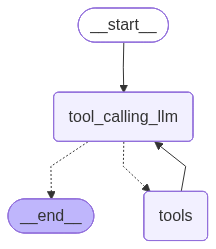

In [ ]:

# stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

# node definition
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

#graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# adding the edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routess to tools
    # if the latest message (result) from assistant is a not a toll call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compiling the graph  
graph=builder.compile(checkpointer=memory)

## visualizing the graph
from IPython.display import display,Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"hi my name is vikas"},config=config)

response 


{'messages': [HumanMessage(content='hi my name is vikas', additional_kwargs={}, response_metadata={}, id='2a3145f7-0511-4e0d-83cb-b8858a066530'),
  AIMessage(content="It's nice to meet you, Vikas. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 1802, 'total_tokens': 1828, 'completion_time': 0.059052385, 'completion_tokens_details': None, 'prompt_time': 0.093159834, 'prompt_tokens_details': None, 'queue_time': 0.161787793, 'total_time': 0.152212219}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e98cd-b03f-7440-8cec-bbf7c6b3a21d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1802, 'output_tokens': 26, 'total_tokens': 1828})]}

In [ ]:
response["messages"][-1].content    

"It's nice to meet you, Vikas. Is there something I can help you with or would you like to chat?"

In [ ]:
response=graph.invoke({"messages":"what is my name"},config=config)

response 

{'messages': [HumanMessage(content='hi my name is vikas', additional_kwargs={}, response_metadata={}, id='2a3145f7-0511-4e0d-83cb-b8858a066530'),
  AIMessage(content="It's nice to meet you, Vikas. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 1802, 'total_tokens': 1828, 'completion_time': 0.059052385, 'completion_tokens_details': None, 'prompt_time': 0.093159834, 'prompt_tokens_details': None, 'queue_time': 0.161787793, 'total_time': 0.152212219}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e98cd-b03f-7440-8cec-bbf7c6b3a21d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1802, 'output_tokens': 26, 'total_tokens': 1828}),
  HumanMessage(content='what is my name', additional_kwargs={}, response_m

In [ ]:
response["messages"][-1].content    

'Your name is Vikas.'

# Streaming


In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [ ]:
def superbot(state:State):
    return{"messages":[llm.invoke(state["messages"])]}

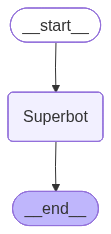

In [ ]:
graph=StateGraph(State)

# node 
graph.add_node("Superbot",superbot)
# edges
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)
graph_builder=graph.compile(checkpointer=memory)

# display
from IPython.display import display,Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:

## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is vikas And I like Runnig"},config)

{'messages': [HumanMessage(content='Hi,My name is vikas And I like Runnig', additional_kwargs={}, response_metadata={}, id='93355554-370d-46a4-906c-4d19c1ff2273'),
  AIMessage(content="Hi Vikas, nice to meet you. Running is a great hobby, it's excellent for physical and mental health. What do you like most about running? Is it the thrill of competition, the sense of accomplishment, or the feeling of freedom that comes with it? Do you have a favorite running spot or a regular running routine?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 49, 'total_tokens': 117, 'completion_time': 0.205222747, 'completion_tokens_details': None, 'prompt_time': 0.001491271, 'prompt_tokens_details': None, 'queue_time': 0.319552307, 'total_time': 0.206714018}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9

# Streaming
## Methods: .stream() and astream()

### These methods are sync and async methods for streaming back results.
### Additional parameters in streaming modes for graph state

#### values : This streams the full state of the graph after each node is called.
#### updates : This streams updates to the state of the graph after each node is called.

## using updates stream mode to get the updates to the state of the graph after each node is called.

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Vikas And I like Running"},config,stream_mode="updates"):
    print(chunk)


{'Superbot': {'messages': [AIMessage(content="Hi Vikas, it's nice to meet you. Running is a great hobby, it's excellent for physical and mental health. Do you have a favorite running route or a specific distance you like to cover? Are you training for any upcoming running events or marathons?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 46, 'total_tokens': 102, 'completion_time': 0.164940912, 'completion_tokens_details': None, 'prompt_time': 0.002169371, 'prompt_tokens_details': None, 'queue_time': 0.160741328, 'total_time': 0.167110283}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e98d8-58b7-7590-a7c9-9b47359ae829-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 56, 'total_tokens': 102})]}}


# values : This streams the full state of the graph after each node is called.

In [ ]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Vikas And I like Running"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Vikas And I like Running', additional_kwargs={}, response_metadata={}, id='ca8151c3-9db3-4cf5-9dc1-d6d397c6006a'), AIMessage(content="Hi Vikas, it's nice to meet you. Running is a great hobby, it's excellent for physical and mental health. Do you have a favorite running route or a specific distance you like to cover? Are you training for any upcoming running events or marathons?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 46, 'total_tokens': 102, 'completion_time': 0.164940912, 'completion_tokens_details': None, 'prompt_time': 0.002169371, 'prompt_tokens_details': None, 'queue_time': 0.160741328, 'total_time': 0.167110283}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e98d8-58b7-7590-a7c9-9b47359ae829-0', tool_calls=[], invalid_tool_c

In [ ]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Vikas and I like to play cricket"]},config,version="v2"):
    print(event)
    
# async used for asynchronous streaming of events, allowing us to process each event as it arrives without blocking the execution of the program.

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Vikas and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e98db-e3b1-7292-95f5-a7d43f079442', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Vikas and I like to play cricket', additional_kwargs={}, response_metadata={}, id='1f7e94cb-d968-4e1a-8e88-f28c788d2758')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019e98db-e3b2-7010-a3a5-0396a8f0af6b', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:7dc4fbcd-a256-3994-ee83-04b6991f11f5'}, 'parent_ids': ['019e98db-e3b1-7292-95f5-a7d43f079442']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':